In [1]:
%load_ext autoreload
%autoreload 2

# Génération des tables "PLEAN"

**Objectif :** Ce notebook constitue le pipeline final pour la création des tables de features pour le Machine Learning. Pour chaque piézomètre cible, il exécute les étapes suivantes :

1.  **Chargement & Nettoyage :** Récupération de la chronique piézométrique brute depuis BigQuery et application du nettoyage (`clean_piezo`).
2.  **Contexte Météo Local :** Recherche des 3 stations Météo-France les plus proches et création de variables synthétiques (`RR_synth`, `TM_synth`, `FFM_synth`) par pondération IDW.
3.  **Calcul de la Pluie Utile :** Estimation de la pluie infiltrée (`PU_synth`) via la méthode de Penman-Monteith.
4.  **Contexte Hydrogéologique Régional :** Recherche des 10 piézomètres voisins les plus pertinents et extraction de leurs 3 premières composantes principales (ACP) pour capturer la tendance de fond régionale.
5.  **Sauvegarde :** Stockage du DataFrame final enrichi en fichier Parquet local.

À la fin, un script consolide tous les fichiers Parquet en une seule table BigQuery `chroniques_plean`, prête pour l'entraînement du modèle XGBoost.

## 0. Configuration et Imports

In [2]:
import os, requests, warnings
import pandas as pd
from hydrosense.params import *

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Controle du repertoire de travail :", os.getcwd())


Controle du repertoire de travail : /home/charourou/projects/Projet_Hydrosense


### 0.a. Paramètres Météo-France

On définit ici l'identifiant du jeu de données Météo-France sur data.gouv.fr pour pouvoir ensuite requêter son API et lister les fichiers disponibles.

In [3]:
CLIM_DATASET_ID='6569b51ae64326786e4e8e1a'
API_URL = f"https://www.data.gouv.fr/api/1/datasets/{CLIM_DATASET_ID}/"

In [4]:
reponse = requests.get(API_URL)
reponse.raise_for_status()

## 1. Import des Précipitations sur le Piézomètre

Avant de lancer le traitement sur l'ensemble des cibles, cette section permet de tester chaque étape du pipeline sur un piézomètre unique choisi au hasard. Cela permet de valider le bon fonctionnement de chaque module (chargement, nettoyage, fusion météo, ACP, etc.).

In [5]:
import random
from google.cloud import bigquery

from hydrosense.preprocess.features import enrichir_contexte_regional
from hydrosense.database.bigquery import load_piezo_bq, info_piezo, save_dataframe_to_bq
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.database.meteo import CatalogueMeteo
from hydrosense.preprocess.meteo_fusion import SynthPrecipitation


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Verification de la location du fichier présent BigQuery:  /home/charourou/projects/Projet_Hydrosense/hydrosense/database/bigquery.py


### 1.a. Chargement, Nettoyage & Contexte Météo

- **`info_piezo`** : Récupère les métadonnées de la cible (département, coordonnées).
- **`load_piezo_bq` & `clean_piezo`** : Charge et nettoie la chronique piézométrique.
- **`SynthPrecipitation`** : Classe utilitaire qui orchestre la recherche des stations météo voisines (`.search()`) et la fusion des données avec calcul des variables synthétiques par pondération IDW (`.merge()`).

In [6]:

random.seed(42)
bss = random.choice(TARGETS_BSS)


info = info_piezo(bss)
departement = str(info['code_departement'].iloc[0])
print('Departement du piezo : ',departement)

df_piezo = clean_piezo(load_piezo_bq(bss))
synthetiseur = SynthPrecipitation(df_piezo, bss)
resultat = synthetiseur.search(departement, n_neighbors=3, dep_voisins= False)
df_final = synthetiseur.merge(resultat)


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Departement du piezo :  79
BSS001PGUQ : 13293 lignes chargées
Trou de 54 jours détecté ! 8072 lignes supprimées.
DataFrame final : 2012-02-13 00:00:00 → 2026-05-30 00:00:00 | 5221 jours


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


🌍 Recherche STRICTE limitée au département : 79...
🌍 Recherche des stations météo pour le département 79...
[{'titre': 'QUOT_departement_79_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_79_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_79_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_79_latest-2025-2026_RR-T-Vent.csv.gz'}]
🔍 Analyse du fichier de référence : QUOT_departement_79_periode_2025-2026_RR-T-Vent
🎯 17 stations actives identifiées pour le 79.
📖 Récupération de l'historique : QUOT_departement_79_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 17 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 791910

### 1.b. Calcul de la Pluie Utile (PU)

La méthode `.calc_PU()` utilise les variables météo synthétiques (`RR_synth`, `TM_synth`, `FFM_synth`) ainsi que la latitude et l'altitude du piézomètre pour estimer l'évapotranspiration (ETP) via la formule de Penman-Monteith.

La Pluie Utile est ensuite calculée simplement : `PU = RR - ETP`.

In [7]:
cols = ['date_mesure','niveau_nappe_eau','RR_synth','TM_synth','FFM_synth']
df_final = df_final[cols]

df_pu = synthetiseur.calc_PU(df_final)
df_pu


💧 Calcul de la Pluie Utile (Penman-Monteith)...


,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth
0,2012-02-13,33.30,1.02,1.72,1.9,-0.002
1,2012-02-14,33.30,0.22,3.66,3.4,-1.234
2,2012-02-15,31.87,0.00,4.87,2.6,-1.381
3,2012-02-16,31.88,0.00,6.39,2.5,-1.466
4,2012-02-17,31.88,0.00,7.13,1.3,-1.149
...,...,...,...,...,...,...
5216,2026-05-26,31.30,0.00,27.68,2.7,-5.579
5217,2026-05-27,31.27,0.00,27.53,2.2,-5.315
5218,2026-05-28,31.23,0.00,27.96,1.9,-5.217
5219,2026-05-29,31.20,0.00,27.32,2.1,-5.256


### 1.c. Chargement du Catalogue des Voisins Hydrogéologiques

Pour l'étape suivante (contexte régional), nous avons besoin de la liste de tous les piézomètres potentiellement "voisins". On charge ici le catalogue `cat_piezo_interm` qui contient les métadonnées de tous les piézomètres de France, pré-filtré pour ne garder que ceux avec un taux de complétude supérieur à 80%.

In [8]:
TABLE = "cat_piezo_interm"
MIN_COMPLETUDE = 0.8

client = bigquery.Client(project=GCP_PROJECT_ID)

query = f"""
            SELECT *
            FROM `{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}`
            WHERE taux_completude > {MIN_COMPLETUDE}
        """
try:
    query_job = client.query(query)
    result = query_job.result()
    cat_clean = result.to_dataframe()
except:
    print("Not uploaded from Big Query")

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 1.d. Enrichissement avec le Contexte Régional (ACP)

La fonction `enrichir_contexte_regional` est le cœur de l'étape 4.
1.  Elle utilise `trouver_voisins_hydrogeologiques` pour identifier les 10 piézomètres les plus pertinents dans le catalogue.
2.  Elle appelle `extraire_PCA_piezo` qui va :
    - Charger les chroniques de ces 10 voisins.
    - Créer une matrice temporelle (dates en index, niveaux en colonnes).
    - Imputer les valeurs manquantes avec `IterativeImputer`.
    - Lisser les séries avec une moyenne mobile.
    - Appliquer une ACP pour extraire les 3 composantes principales (`PC1_hydro`, `PC2_hydro`, `PC3_hydro`).
3.  Enfin, elle fusionne ces nouvelles features au DataFrame de notre piézomètre cible.

In [9]:
# ÉTAPE 4 & 5 : Contexte Régional (Voisins) + Jointure
df_enrichi = enrichir_contexte_regional(
        df_cible=df_pu,
        bss_cible=bss,
        df_catalogue=cat_clean,
        n_voisins=10
    )



🌍 ÉTAPE 4 : Recherche du contexte régional pour BSS001PGUQ...
   ✔️ 10 voisins trouvés. Calcul de l'ACP...
🔄 Récupération et alignement des voisins...
BSS001PHQG : 13682 lignes chargées
Trou de 292 jours détecté ! 5081 lignes supprimées.
DataFrame final : 2002-06-17 00:00:00 → 2026-05-30 00:00:00 | 8749 jours
BSS001PHKF : 12101 lignes chargées
DataFrame final : 1993-03-09 00:00:00 → 2026-05-30 00:00:00 | 12136 jours
BSS001PKJB : 11771 lignes chargées
Trou de 73 jours détecté ! 3211 lignes supprimées.
DataFrame final : 2002-06-12 00:00:00 → 2026-05-30 00:00:00 | 8754 jours
BSS001PHJU : 13062 lignes chargées
Trou de 185 jours détecté ! 2320 lignes supprimées.
DataFrame final : 1997-01-01 00:00:00 → 2026-05-30 00:00:00 | 10742 jours
BSS001PHJT : 12918 lignes chargées
Trou de 185 jours détecté ! 2221 lignes supprimées.
DataFrame final : 1997-01-01 00:00:00 → 2026-05-30 00:00:00 | 10742 jours


KeyboardInterrupt: 

### 1.e. Sauvegarde locale du fichier de test

Le DataFrame enrichi pour ce piézomètre de test est sauvegardé en local pour inspection.

In [ ]:
print(df_enrichi.columns)
print(df_enrichi.describe())

DOSSIER_SORTIE = 'data/processed_pem/'
fichier_sortie = os.path.join(DOSSIER_SORTIE, f"pem_{bss}.parquet")
df_enrichi.to_parquet(fichier_sortie, index=False, compression='snappy')

Index(['date_mesure', 'niveau_nappe_eau', 'RR_synth', 'TM_synth', 'FFM_synth',
       'PU_synth', 'PC1', 'PC2', 'PC3', 'PC1_hydro', 'PC2_hydro', 'PC3_hydro'],
      dtype='object')
               date_mesure  niveau_nappe_eau     RR_synth     TM_synth  \
count                 5221       5221.000000  5221.000000  5221.000000   
mean   2019-04-07 00:00:00         31.468726     2.445260    13.260506   
min    2012-02-13 00:00:00         28.110000     0.000000    -3.530000   
25%    2015-09-10 00:00:00         30.510000     0.000000     8.670000   
50%    2019-04-07 00:00:00         31.670000     0.090000    12.930000   
75%    2022-11-02 00:00:00         32.720000     2.420000    17.990000   
max    2026-05-30 00:00:00         33.730000    59.250000    32.360000   
std                    NaN          1.378871     5.162514     6.255581   

         FFM_synth     PU_synth          PC1          PC2          PC3  \
count  5213.000000  5221.000000  5221.000000  5221.000000  5221.000000   
mean

## 2. Lancement du Pipeline sur Toutes les Cibles

Cette cellule est le cœur du notebook. Elle itère sur la liste `TARGETS_BSS` et applique l'ensemble du pipeline (étapes 1 à 5 décrites ci-dessus) à chaque piézomètre.

Chaque DataFrame final est sauvegardé individuellement dans le dossier `data/processed_pem/` sous forme de fichier Parquet compressé (`pem_BSSXXXX.parquet`).

La boucle est encapsulée dans un `try...except` pour garantir que l'échec sur un piézomètre n'interrompt pas le traitement des suivants.

In [ ]:

for i, bss in enumerate(TARGETS_BSS[2:]):


    try:
        info = info_piezo(bss)
        departement = str(info['code_departement'].iloc[0])

        print('\n' + '='*60)
        print(f'[{i+1}/{len(TARGETS_BSS)}] 🎯 Traitement de : {bss} (Dép: {departement})')

        # --- ÉTAPE 1 : Chargement Target (chronique brute propre) ---
        df_piezo = clean_piezo(load_piezo_bq(bss))
        synthetiseur = SynthPrecipitation(df_piezo, bss)

        # --- ÉTAPE 2 : Contexte Météo local ---
        resultat_meteo = synthetiseur.search(departement, dep_voisins=False)
        df_final = synthetiseur.merge(resultat_meteo)

        # --- ÉTAPE 3 : Pluie Utile (Physique) ---
        df_final = synthetiseur.calc_PU(df_final)

        # --- ÉTAPE 4 & 5 : Contexte Régional (Voisins) + Jointure ---
        df_final = enrichir_contexte_regional(
            df_cible=df_final,
            bss_cible=bss,
            df_catalogue=cat_clean,
            n_voisins=10
        )

        # --- ÉTAPE 6 : Sauvegarde locale en Parquet compressé ---
        fichier_sortie = os.path.join(DOSSIER_SORTIE, f"pem_{bss}.parquet")
        print(f"💾 Sauvegarde en cours vers : {fichier_sortie}")

        df_final.to_parquet(fichier_sortie, index=False, compression='snappy')

        print(f"🎉 Succès pour {bss} ! Dimensions finales : {df_final.shape}")

    except Exception as e:
        # Sécurité : On attrape toute erreur inattendue pour ne pas stopper la boucle
        print(f"❌ Échec critique sur le piézomètre {bss} : {e}")
        print("⏩ Passage au piézomètre suivant...")
        continue

    print("\n✅ PROCESSUS TERMINÉ ! Vous pouvez maintenant lancer l'upload vers BigQuery.")


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



[1/19] 🎯 Traitement de : BSS000ZQXN (Dép: 35)
BSS000ZQXN : 7682 lignes chargées
Trou de 62 jours détecté ! 1176 lignes supprimées.
DataFrame final : 2008-07-09 00:00:00 → 2026-05-29 00:00:00 | 6534 jours


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


🌍 Recherche STRICTE limitée au département : 35...
🌍 Recherche des stations météo pour le département 35...
[{'titre': 'QUOT_departement_35_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_35_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_35_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_35_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_35_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_35_latest-2025-2026_RR-T-Vent.csv.gz'}]
🔍 Analyse du fichier de référence : QUOT_departement_35_periode_2025-2026_RR-T-Vent
🎯 18 stations actives identifiées pour le 35.
📖 Récupération de l'historique : QUOT_departement_35_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 18 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 350050

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


...

🌍 Recherche STRICTE limitée au département : 47...
🌍 Recherche des stations météo pour le département 47...
[{'titre': 'QUOT_departement_47_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_47_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_47_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_47_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_47_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_47_latest-2025-2026_RR-T-Vent.csv.gz'}]
🔍 Analyse du fichier de référence : QUOT_departement_47_periode_2025-2026_RR-T-Vent
🎯 14 stations actives identifiées pour le 47.
📖 Récupération de l'historique : QUOT_departement_47_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 14 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 473230

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



[17/19] 🎯 Traitement de : BSS002EDYK (Dép: 40)
BSS002EDYK : 12108 lignes chargées
DataFrame final : 1992-10-23 00:00:00 → 2026-05-18 00:00:00 | 12261 jours


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


🌍 Recherche STRICTE limitée au département : 40...
🌍 Recherche des stations météo pour le département 40...
[{'titre': 'QUOT_departement_40_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_40_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_40_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_40_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_40_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_40_latest-2025-2026_RR-T-Vent.csv.gz'}]
🔍 Analyse du fichier de référence : QUOT_departement_40_periode_2025-2026_RR-T-Vent
🎯 17 stations actives identifiées pour le 40.
📖 Récupération de l'historique : QUOT_departement_40_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 17 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 402860

## 3. Consolidation et Upload vers BigQuery

Maintenant que tous les fichiers Parquet individuels ont été générés, cette dernière étape les consolide en un unique DataFrame pandas, puis l'upload vers la table `chroniques_plean` dans BigQuery.

Cette table finale sera la source de données unique pour l'entraînement et l'évaluation du modèle XGBoost.

In [ ]:
from hydrosense.params import *
GCP_PROJECT_ID, BQ_DATASET_ID

('hydro-sense-498112', 'piezometry')

In [ ]:
from hydrosense.database.parquet import upload_chroniques_plean

upload_chroniques_plean()


📥 1. Lecture et fusion des fichiers Parquet locaux (Features ML)...
pem_BSS002BGAF
pem_BSS002EDYK
pem_BSS001QHPU
pem_BSS001WVPW
pem_BSS002AFGV
pem_BSS002DEZW
pem_BSS001PGUQ
pem_BSS002AXYY
pem_BSS001QSMT
pem_BSS001QTKG
pem_BSS001SHNE
pem_BSS001UCZQ
pem_BSS001QHYH
pem_BSS001VAJT
pem_BSS001RQQE
pem_BSS000ZQXN
pem_BSS000ZPHJ
pem_BSS002CAAM
pem_BSS001XBKZ
💾 2. Création du cache local : /home/charourou/projects/Projet_Hydrosense/data/processed_pem/all_chroniques_plean.parquet
🚀 3. Upload de 163963 lignes vers BigQuery (chroniques_plean)...


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Upload terminé avec succès ! La table chroniques_plean est prête pour XGBoost.


## 4. Vérification

Pour s'assurer que l'upload s'est bien déroulé, on teste la fonction `load_plean` qui recharge les données d'un piézomètre spécifique depuis la table BigQuery finale.

In [ ]:
from hydrosense.database.bigquery import load_plean

load_plean(bss)

✅ BSS002EDYK : 12261 lignes de features ML chargées.


,bss_id,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth,PC1,PC2,PC3
0,BSS002EDYK,1992-10-23,28.14,5.93,12.00,2.9,3.860,3.915226,0.464661,0.886064
1,BSS002EDYK,1992-10-24,28.18,12.11,12.50,3.4,9.859,3.948009,0.468551,0.893483
2,BSS002EDYK,1992-10-25,28.30,9.84,14.70,5.0,6.933,3.977514,0.472052,0.900160
3,BSS002EDYK,1992-10-26,28.38,5.14,13.20,1.9,3.397,4.003740,0.475164,0.906096
4,BSS002EDYK,1992-10-27,28.38,3.76,14.10,4.1,1.191,4.026688,0.477887,0.911289
...,...,...,...,...,...,...,...,...,...,...
12256,BSS002EDYK,2026-05-14,26.96,16.50,11.75,5.0,12.807,1.696960,0.659848,-0.138771
12257,BSS002EDYK,2026-05-15,26.97,4.03,11.11,3.2,0.667,1.673158,0.658903,-0.076227
12258,BSS002EDYK,2026-05-16,27.03,1.86,11.95,2.7,-1.534,1.759426,0.635670,-0.040679
12259,BSS002EDYK,2026-05-17,27.05,1.96,13.85,2.6,-1.661,1.885524,0.591335,-0.037464


---
## Annexe : Analyse Exploratoire & Brouillons

Cellules de test et anciennes versions du code conservées pour référence.

In [ ]:

# Production des ple
for bss in TARGETS_BSS[:]:
    info = info_piezo(bss)
    departement = str(info['code_departement'].iloc[0])
    print('Departement du piezo : ',departement)

    df_piezo = clean_piezo(load_piezo_bq(bss))
    synthetiseur = SynthPrecipitation(df_piezo, bss)
    resultat = synthetiseur.search(departement)
    df_final = synthetiseur.merge(resultat)

    if False:
        print(df_final.sample(15), df_final.info())

    save_dataframe_to_bq(df_final, bss,  write_mode="WRITE_TRUNCATE")


#### 0.4 Nouvelle fonction pour uploader les PEMs vers bigquery 

`save_dataframe_to_bq(df_final, bss,  write_mode="WRITE_TRUNCATE")`


In [ ]:
# from google.cloud import bigquery
# # Send the fusion df to big query as a pem name: "pem_" + bss
# TABLE = "pem_" + bss
# table = f"{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}"

# client = bigquery.Client()

# write_mode = "WRITE_TRUNCATE" # or "WRITE_APPEND"
# job_config = bigquery.LoadJobConfig(write_disposition=write_mode)

# job = client.load_table_from_dataframe(df_final, table, job_config=job_config)
# result = job.result()


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


### 1. Le "Sanity Check" (L'état des lieux)

Regarder la complétude et la distribution des données synthétiques.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print("Valeurs manquantes par colonne :")
print(df_final.isna().sum())

print("\nStatistiques descriptives :")
print(df_final[['RR_synth', 'TM_synth', 'niveau_nappe_eau']].describe())


Valeurs manquantes par colonne :
date_mesure             0
niveau_nappe_eau        0
RR_40286001           121
TM_40286001         10767
FFM_40286001        12261
RR_40192001             0
TM_40192001             3
FFM_40192001            2
RR_40031001            31
TM_40031001         10262
FFM_40031001        12261
RR_synth                0
TM_synth                3
FFM_synth               2
dtype: int64

Statistiques descriptives :
           RR_synth     TM_synth  niveau_nappe_eau
count  12261.000000  12258.00000      12261.000000
mean       2.791557     13.53265         26.830740
std        5.688511      6.44205          0.623677
min        0.000000     -6.80000         25.410000
25%        0.000000      8.83750         26.350000
50%        0.140000     13.50000         26.800000
75%        2.860000     18.60000         27.230000
max       63.780000     30.11000         29.300000


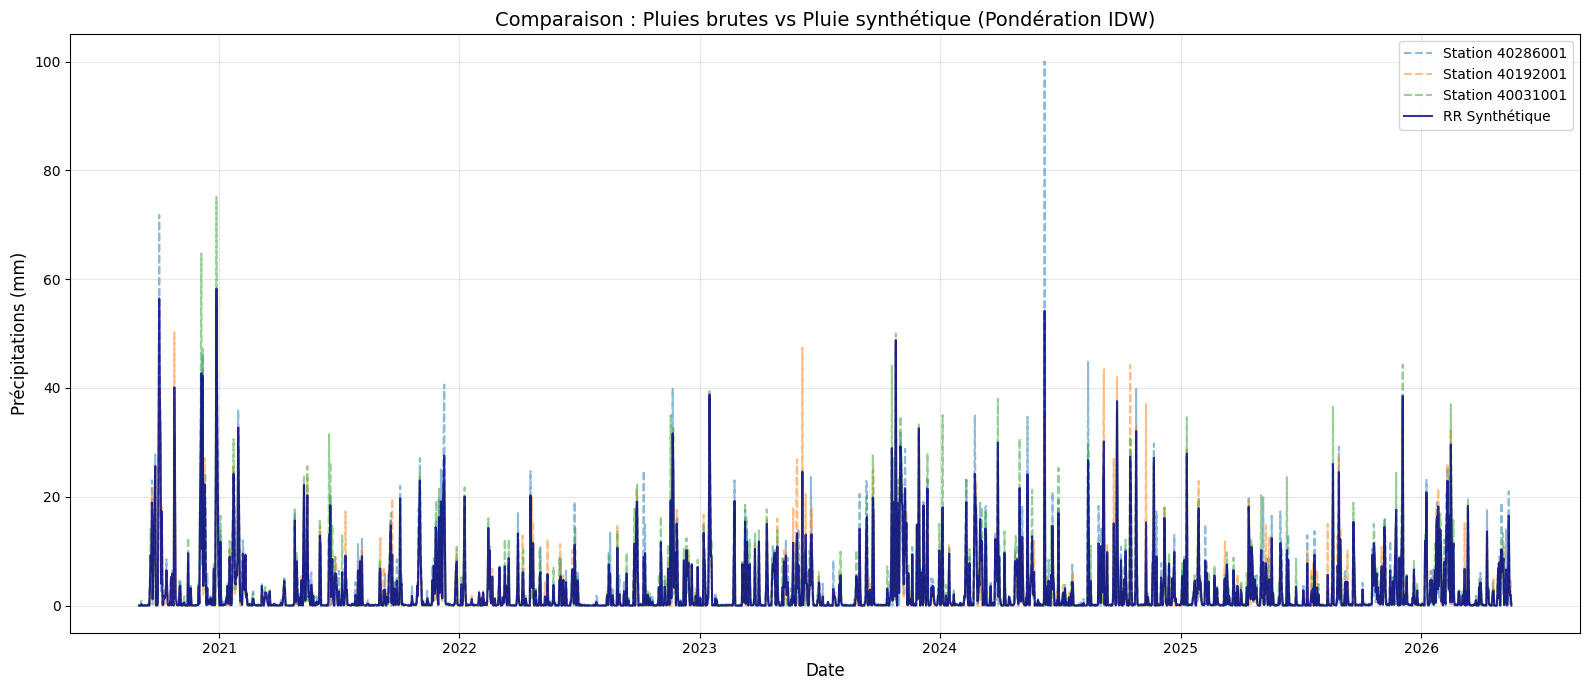

In [ ]:
start_date = '2020-09-01'
end_date = '2026-09-01'
mask = (df_final['date_mesure'] >= start_date) & (df_final['date_mesure'] <= end_date)
df_zoom = df_final.loc[mask]

# 2. Identification des colonnes
cols_rr = [c for c in df_final.columns if ('RR_' in c and c[-1].isnumeric())]
col_synth = 'RR_synth'


plt.figure(figsize=(16, 7))
for col in cols_rr:
    plt.plot(df_zoom['date_mesure'], df_zoom[col], alpha=0.5, linestyle='--', label=f"Station {col.split('_')[1]}")

# Tracé de la synthèse avec une ligne plus épaisse et colorée
plt.plot(df_zoom['date_mesure'], df_zoom[col_synth], alpha = 0.8, color='darkblue', linewidth=1.5, label='RR Synthétique')

plt.title(f"Comparaison : Pluies brutes vs Pluie synthétique (Pondération IDW)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Précipitations (mm)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## 2. L'Hydrogramme Pluie-Niveau

En hydrogéologie, l'hydrogramme avec les précipitations inversées en haut (qui "tombent" vers le bas) et le niveau de la nappe en bas. C'est ce qui permet de voir "à l'œil nu" si la nappe réagit vite aux épisodes pluvieux.

Créer un graphique à double axe

In [ ]:
df_zoom = df_final[(df_final['date_mesure'] >= '2015-01-01') & (df_final['date_mesure'] <= '2018-01-01')]
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Niveau de la nappe (m)', color=color)
ax1.plot(df_zoom['date_mesure'], df_zoom['niveau_nappe_eau'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# La pluie synthétique (en gris/bleu clair, inversé)
ax2 = ax1.twinx()
color = 'tab:gray'
ax2.set_ylabel('Précipitations (mm)', color=color)
ax2.bar(df_zoom['date_mesure'], df_zoom['RR_synth'], color=color, alpha=0.5, width=1)
ax2.tick_params(axis='y', labelcolor=color)

# On inverse l'axe des ordonnées pour la pluie (effet "chute d'eau")
ax2.set_ylim(ax2.get_ylim()[::-1])
ax2.set_ylim(df_zoom['RR_synth'].max() * 2, 0)

plt.title("Hydrogramme : Réaction de la nappe face aux précipitations")
fig.tight_layout()
plt.show()

NameError: name 'df_final' is not defined

## 3. La Recherche du "Temps de Réponse" (Cross-Correlation)

L'eau met du temps à s'infiltrer à travers le sol pour atteindre l'aquifère. S'il pleut aujourd'hui, le niveau de la nappe ne montera peut-être que dans 10, 20 ou 40 jours.

Calculer la corrélation croisée (Lags) pour trouver le délai de recharge.

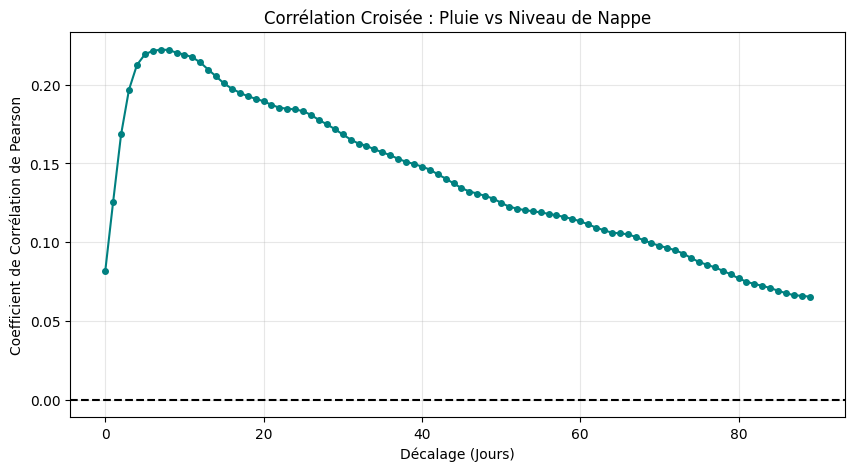

Le temps de réponse optimal estimé de la nappe est de 7 jours.


In [ ]:
# On s'assure de ne pas avoir de NaN pour le calcul de corrélation
df_corr = df_final[['RR_synth', 'niveau_nappe_eau']].dropna()

lags = range(0, 90) # On teste des décalages de 0 à 90 jours
corr_values = []

for lag in lags:
    # On décale la pluie vers le futur (ou le niveau vers le passé)
    # Pour voir si la pluie du jour J est corrélée au niveau du jour J+lag
    corr = df_corr['RR_synth'].corr(df_corr['niveau_nappe_eau'].shift(-lag))
    corr_values.append(corr)

plt.figure(figsize=(10, 5))
plt.plot(lags, corr_values, marker='o', color='teal', markersize=4)
plt.axhline(0, color='black', linestyle='--')
plt.title("Corrélation Croisée : Pluie vs Niveau de Nappe")
plt.xlabel("Décalage (Jours)")
plt.ylabel("Coefficient de Corrélation de Pearson")
plt.grid(True, alpha=0.3)
plt.show()

best_lag = lags[np.argmax(np.abs(corr_values))]
print(f"Le temps de réponse optimal estimé de la nappe est de {best_lag} jours.")

## 4. Une petite Heatmap

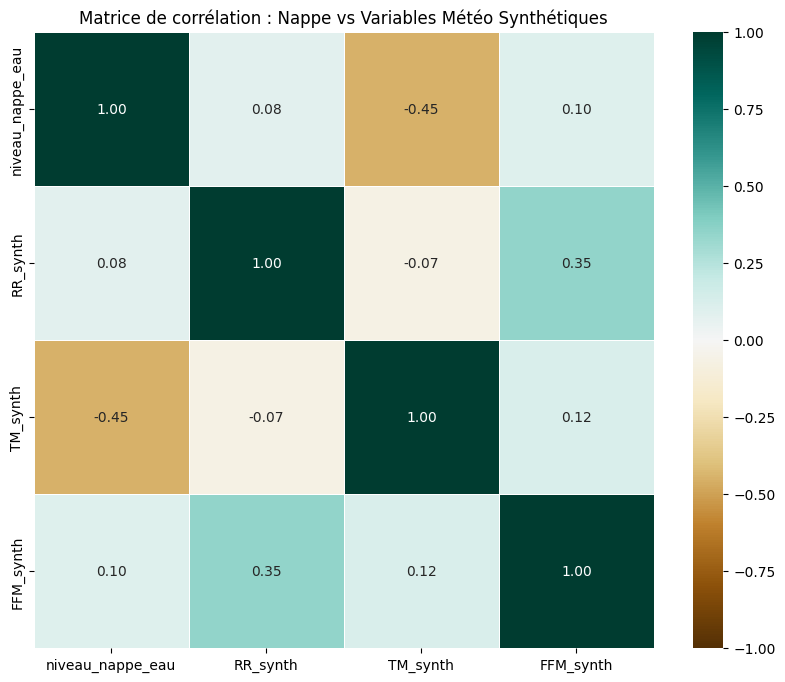

In [ ]:
# 1. Calcul de la matrice de corrélation
# On sélectionne uniquement les colonnes numériques pertinentes
cols_to_corr = ['niveau_nappe_eau', 'RR_synth', 'TM_synth','FFM_synth']
corr_mat = df_final[cols_to_corr].corr()

# 2. Configuration de la figure
plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Variables Météo Synthétiques")
plt.show()